In [24]:
#modified wa

output_folder_name = '5-8-2026_data-init-with-SA_curtains_paper_total_R2_4_parameters'
# Dendrogram_output_file_name = 'Dendrogram_qr_by_(qr+qs+qg)_using_all_locals.png' #write .png
# HC_output_file_name = 'HC_qr_by_(qr+qs+qg)_using_all_locals.csv' #write .csv
pred_vs_actual_output_file_name = 'Pred_vs_Actual_qr_by_(qr+qs+qg)_using_all_locals.png' #write .png

import time
overall_start_time = time.time()
import os
import importlib
import sys

# #Remove cached modules
# for module_name in list(sys.modules.keys()):
#     if 'dataset_init' in module_name:
#         del sys.modules[module_name]

# #Reimport
# from Tools import dataset_init

#To go up one level from 'Codes' sub-folder to 'MS' Folder, then the other sub-folders such as 'File_management' are accessible
MS_PATH = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(MS_PATH)

import numpy as np
import pandas as pd
#%matplotlib inline  #won't work for .py
import matplotlib.pyplot as plt
import xarray as xr

from File_management import json_file_editer as JFE
from Calculation import job_manager 
# from Tools import dataset_init
from Tools import data_init_with_SA as dataset_init
from Tools import thermodynamics
from Log_management import Log

import xgboost as xgb
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score

#random forest
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')

#ISLP
from matplotlib.pyplot import subplots
from statsmodels.datasets import get_rdataset
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
# from ISLP.models import ModelSpec as MS

from sklearn.tree import (DecisionTreeClassifier as DTC,
 DecisionTreeRegressor as DTR,
 plot_tree,
 export_text)
from sklearn.metrics import (accuracy_score,
 log_loss)
from sklearn.ensemble import \
 (RandomForestRegressor as RF,
 GradientBoostingRegressor as GBR)
from ISLP.bart import BART
import joblib

import csv
from Tools.data_init_with_SA import saturation_adjustment_newton

#################################################################
# Log.init_log(os.path.join('./output'), filename=f"Log_ML.txt")
Log.init_log(os.path.join(MS_PATH, 'output'), filename="Log_ML.txt")
Log.add_to_log("Log nicely initialized ")

# options_json=JFE.get_json_data("options.json")
options_json = JFE.get_json_data(os.path.join(MS_PATH, "options.json"))

options_json["Header"]["status"]
chunks = {}
myJob = job_manager.JobManager(options_json)
# ds = dataset_init.ds_init_3d(myJob, chunks={}) 
ds = dataset_init.ds_init(myJob, chunks={}) 

The job folder path : /home/m/m301214/MS/output/Log_ML.txt
2026 Aug 05 11:54:55 > Log nicely initialized 
2026 Aug 05 11:54:55 > (DI0010) making data from P-O files requires small differences in the code, hardly automisable.
2026 Aug 05 11:54:55 > (DI0020) Starting PO dataset creation from /work/mh0066/m301130/projects/scheme_comparison/icon-mpim/build/experiments/pod0003
2026 Aug 05 11:54:55 > (DI0021) Found 35 time-varying files in date range
2026 Aug 05 11:54:55 > (DI0022) Loading vertical grid data from /work/mh0066/m301130/projects/scheme_comparison/icon-mpim/build/experiments/pod0003/pod0003_atm_vgrid_ml.nc
2026 Aug 05 11:54:55 > (DI0023) Grid variables available: ['clon_bnds', 'clat_bnds', 'height_bnds', 'height_2_bnds', 'zghalf', 'zg', 'dzghalf', 'clon', 'clat', 'height', 'height_2']
2026 Aug 05 11:54:55 > (DI0024) Dimensions in vgrid: {'ncells': 20971520, 'vertices': 3, 'height': 60, 'bnds': 2, 'height_2': 60}
2026 Aug 05 11:54:55 > (DI0037) Loading horizontal grid data from /

2026 Aug 05 11:54:55 > (DI0039) Successfully loaded cell areas from /pool/data/ICON/grids/public/mpim/0055/icon_grid_0055_R02B09_G.nc
2026 Aug 05 11:54:56 > (DI0019) Combining 5 time-varying datasets
2026 Aug 05 11:55:01 > (DI0018) Merging time-varying data with vertical grid data
2026 Aug 05 11:55:01 > (DI0017) Common dimensions: {'height_2', 'height', 'bnds', 'ncells'}
2026 Aug 05 11:55:01 > (DI0016) Successfully merged with vertical grid data
2026 Aug 05 11:55:01 > (DI0074) Merging with horizontal grid data (cell areas)
2026 Aug 05 11:55:01 > (DI0073) Renamed 'cell' dimension to 'ncells'
2026 Aug 05 11:55:01 > (DI0071) After renaming - common dimensions: {'ncells'}
2026 Aug 05 11:55:03 > (DI0075) Successfully merged cell area data
2026 Aug 05 11:55:03 > (DI0033) Selected variables: ['cell_area', 'clat', 'cli', 'clivi', 'cllvi', 'clon', 'clw', 'dzghalf', 'hus', 'pfull', 'pr', 'qg', 'qgvi', 'qr', 'qrvi', 'qs', 'qsvi', 'rho', 'ta', 'tas', 'ua', 'va', 'wa', 'zg']
2026 Aug 05 11:55:03 > 

In [25]:
ds

<xarray.Dataset> Size: 78GB
Dimensions:    (ncells: 20971520, time: 1, height: 61, height_2: 61)
Coordinates:
    clon       (ncells) float64 168MB dask.array<chunksize=(20971520,), meta=np.ndarray>
    clat       (ncells) float64 168MB dask.array<chunksize=(20971520,), meta=np.ndarray>
  * time       (time) datetime64[ns] 8B 2020-01-12
  * height     (height) float64 488B 2.0 31.0 32.0 33.0 ... 87.0 88.0 89.0 90.0
  * height_2   (height_2) float64 488B 10.0 31.0 32.0 33.0 ... 88.0 89.0 90.0
Dimensions without coordinates: ncells
Data variables: (12/22)
    cell_area  (ncells) float64 168MB dask.array<chunksize=(20971520,), meta=np.ndarray>
    pr         (time, ncells) float32 84MB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    tas        (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
    clivi      (time, ncells) float32 84MB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    cllvi      (time, ncells) float32 84MB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    qgvi       (time, ncells) float32 84MB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    ...         ...
    rho        (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
    dzghalf    (height, ncells) float32 5GB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    zg         (height_2, ncells) float32 5GB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    ua         (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
    va         (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
    pfull      (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
Attributes: (12/48)
    CDI:                               Climate Data Interface version 2.5.2.1...
    Conventions:                       CF-1.6
    number_of_grid_used:               55
    grid_file_uri:                     http://icon-downloads.mpimet.mpg.de/gr...
    uuidOfHGrid:                       9a8d03ba-2027-11ef-a2ba-c74e1b4d7fe9
    institution:                       Max Planck Institute for Meteorology/D...
    ...                                ...
    subcentre:                         0
    ICON_grid_file_uri:                http://icon-downloads.mpimet.mpg.de/gr...
    optimization:                      spring dynamics
    NCO:                               netCDF Operators version 5.0.6 (Homepa...
    saturation_adjustment:             newton_liquid_water_energy_conserving
    saturation_adjustment_iterations:  6

In [26]:
#Functions

# #RH from SH
# def RH_from_SH(P, SH, T, T_0= 273.16):
#     RH = 0.26 * P * SH / np.exp(17.67 * (T - T_0) / (T - 29.65))
#     return RH

# #Modified R2 score
# def modified_r_squared(y_test, y_test_pred, y_train):
#     # Calculate the mean of the actual values
#     mean_y_train = np.mean(y_train)

#     # Calculate the total sum of squares
#     ss_total = np.sum((y_test - mean_y_train)**2)

#     # Calculate the residual sum of squares
#     ss_residual = np.sum((y_test - y_test_pred)**2)

#     # Calculate R^2 score
#     r2_score = 1 - (ss_residual / ss_total)

#     return r2_score

#Weighted R2 score 
def weighted_r_squared(y_true, y_pred, weight, y_train):
    # Calculate the mean of the actual values
    mean_y_train = np.mean(y_train)
    mean_y_true = np.mean(y_true)
    ss_total = np.sum( weight * (y_true - mean_y_train)**2)
    ss_residual = np.sum( weight * (y_true - y_pred)**2)
    r2_score = 1 - (ss_residual / ss_total)
    return r2_score

def apply_saturation_adjustment_to_curtain(curtain):
    qti = curtain["qi"] + curtain["qg"] + curtain["qs"]
    qv_adjusted, qc_adjusted, ta_adjusted = saturation_adjustment_newton(
        qv=curtain["qv"],
        ql=curtain["qc"],
        tk=curtain["ta"],
        rho=curtain["rho"],
        qr=curtain["qr"],
        qti=qti,
        n_iter=6,
    )

    curtain = curtain.assign(
        qv=qv_adjusted,
        qc=qc_adjusted,
        ta=ta_adjusted,
    )
    curtain["qv"].attrs.update({"saturation_adjusted": "newton"})
    curtain["qc"].attrs.update({"saturation_adjusted": "newton"})
    curtain["ta"].attrs.update({"saturation_adjusted": "newton"})
    curtain.attrs["saturation_adjustment"] = "newton_liquid_water_energy_conserving"
    curtain.attrs["saturation_adjustment_iterations"] = 6
    return curtain


In [27]:
#Numerator and Denominator for the weighted R2 score
numerator_across_all_curtains = 0
denominator_across_all_curtains = 0

def numerator_denominator_across_all_curtains(y_true, y_pred, weight, y_train):
    # Calculate the mean of the actual values
    mean_y_train = np.mean(y_train)
    # mean_y_true = np.mean(y_true)
    ss_total = np.sum( weight * (y_true - mean_y_train)**2)
    ss_residual = np.sum( weight * (y_true - y_pred)**2)

    return ss_residual, ss_total
    

In [28]:
#Rename variables as per our notation
ds = ds.rename({'clw': 'ql'})
ds = ds.rename({'cli': 'qi'})
ds = ds.rename({'ta': 'T'})
ds = ds.rename({'hus': 'SH'})
ds = ds.rename({'pfull': 'P'})
ds = ds.rename({'cllvi': 'CLWP'})
ds = ds.rename({'clivi': 'CIP'})
ds = ds.rename({'wa': 'upward_air_velocity'})
ds = ds.rename({'ua': 'zonal_wind'})
ds = ds.rename({'va': 'meridional_wind'})
ds = ds.rename({'rho': 'air_density'})

In [29]:
wa_renamed = ds.sel(height=slice(31.0, 90.0), height_2=slice(31.0, 90.0))['upward_air_velocity'].rename({'height_2': 'height'})
ds = (
    ds
    .sel(height=slice(31.0, 90.0), height_2=slice(31.0, 90.0))
    .assign(upward_air_velocity=wa_renamed)
)

In [30]:
#Data Pre-processing

#subset of the original dataset

seed = 1
# sample_frac = 0.001

ht=31
data=ds.sel(height=ht, height_2=ht) 

In [31]:
#Graupel Threshold set to 1e-6 kg/kg as mentioned in Michibata, 2024
# data = data.where(data['qg'] >= 1e-6)

total = data['ql'] + data['qi']
data['ql/(ql+qi)'] = data['ql'].where(total != 0, 0) / total.where(total != 0, 1)
data['qi/(ql+qi)'] = data['qi'].where(total != 0, 0) / total.where(total != 0, 1)

total_precipitates = data['qr'] + data['qs']+ data['qg']
data['qr/(qr+qs+qg)'] = data['qr'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
data['qs/(qr+qs+qg)'] = data['qs'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
data['qg/(qr+qs+qg)'] = data['qg'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)

df = data.to_dataframe() #.sample(frac=1, random_state=seed) #frac=sample_frac

#threshold
threshold = 5e-12
df_new = df[(df['ql'] + df['qi'] + df['qr'] + df['qg'] + df['qs']) >= threshold]

if df_new.empty:
    df_new = df

df = df_new
# df = data.to_dataframe().sample(frac=sample_frac, random_state=seed)

dfs = [df]  
# for ht in range(32, 91, 5): #(32, 91, 5)
for ht in range(36, 91, 5): #(44, 91, 4)
    data = ds.sel(height=ht, height_2=ht)
    #Graupel Threshold set to 1e-6 kg/kg as mentioned in Michibata, 2024
    # data = data.where(data['qg'] >= 1e-6)

    total = data['ql'] + data['qi']
    data['ql/(ql+qi)'] = data['ql'].where(total != 0, 0) / total.where(total != 0, 1)
    data['qi/(ql+qi)'] = data['qi'].where(total != 0, 0) / total.where(total != 0, 1)

    total_precipitates = data['qr'] + data['qs']+ data['qg']
    data['qr/(qr+qs+qg)'] = data['qr'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
    data['qs/(qr+qs+qg)'] = data['qs'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
    data['qg/(qr+qs+qg)'] = data['qg'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)

    df_sampled=data.to_dataframe() #.sample(frac=1, random_state= seed+ht) #frac=sample_frac

    #threshold
    threshold = 5e-12
    df_sampled_new = df_sampled[(df_sampled['ql'] + df_sampled['qi'] + df_sampled['qr'] + df_sampled['qg'] + df_sampled['qs']) >= threshold]

    if df_sampled_new.empty:
        df_sampled_new = df_sampled

    df_sampled = df_sampled_new

    dfs.append(df_sampled) 


    print(f"Last value of clon in df with height {ht} is", df_sampled['clon'].iloc[-1])

df = pd.concat(dfs, ignore_index=True)


prod= len(dfs[0]) * len(dfs)
print("Expected length of df: ", prod)
print('Final length of df: ', len(df))


#OBtain lon and lat from clon and clat respectively
df['lon'] = df['clon']*180/np.pi #in degrees
df['lat'] = df['clat']*180/np.pi #in degrees

# #Setting coordinates range as the range of coordinates in Curtains dataset

# print("Minimum latitude: ", df['lat'].min())
# print("Maximum latitude: ", df['lat'].max())
# print("Minimum longitude: ", df['lon'].min())
# print("Maximum longitude: ", df['lon'].max())

# len_df_before_coordinate_slicing = len(df)
# print("Length of df before coordinate slicing: ", len_df_before_coordinate_slicing)

# #Slice the df
# df = df[(df['lat'].between(-4, 23)) & (df['lon'].between(-62, -20))] #These are the range of values of coordinates in the Curtains dataset

# print("Minimum latitude: ", df['lat'].min())
# print("Maximum latitude: ", df['lat'].max())
# print("Minimum longitude: ", df['lon'].min())
# print("Maximum longitude: ", df['lon'].max())

# len_df_after_coordinate_slicing = len(df)
# print("Length of df after coordinate slicing: ", len_df_after_coordinate_slicing)

# #threshold
# threshold = 5e-12
# df_new = df[(df['qi'] + df['ql'] + df['qr'] + df['qg'] + df['qs']) >= threshold]

# if df_new.empty:
#     df_new = df

# df = df_new



Last value of clon in df with height 36 is -0.8223929610480394
Last value of clon in df with height 41 is 1.8954505568741382
Last value of clon in df with height 46 is 1.2075635365782438
Last value of clon in df with height 51 is 1.274090353955931
Last value of clon in df with height 56 is 1.3343108942333097
Last value of clon in df with height 61 is 1.3311654584247423
Last value of clon in df with height 66 is 1.3053725942366794
Last value of clon in df with height 71 is 1.1805524665406022
Last value of clon in df with height 76 is 1.1895574133799796
Last value of clon in df with height 81 is 1.4321668545733466
Last value of clon in df with height 86 is 1.3343108942333097
Expected length of df:  976224
Final length of df:  58810458


In [32]:
#RH data

# df['RH']=RH_from_SH(df['P'], df['SH'], df['T'])
df['RH'] = thermodynamics.relative_humidity_water(df['SH'], df['T'], df['air_density'])

In [33]:
count=0
for i in df['RH']:
    if i>100 or i<0:
        count+=1
print("out-of-range count = ", count)
print("out-of-range count percent = ", 100*count/len(df['RH']), " %")

df['RH']= df['RH'].clip(lower=0, upper=100)

#Insert variables to the df
col=df.pop('RH')
df.insert(16, 'RH', col) #SH is at 15th position
#df.pop('SH')

out-of-range count =  0
out-of-range count percent =  0.0  %


In [34]:
df['ql+qi']=df['ql']+df['qi']
col=df.pop('ql+qi')
df.insert(26, 'ql+qi', col) 

#Include 'cloud liquid water path + cloud ice path' as a feature.
df['CLWP+CIP']=df['CLWP']+df['CIP']
col=df.pop('CLWP+CIP')
df.insert(27, 'CLWP+CIP', col) 

#Adding another column; qr+qg+qs and use it later as an input feature
df['qr+qg+qs'] = df['qr'] + df['qg'] + df['qs']
col=df.pop('qr+qg+qs')
df.insert(30, 'qr+qg+qs', col)

df['qr/(qr+qs+qg)'] = df['qr'] / (df['qr']+ df['qs'] + df['qg']) 
# print('Number of NaN values in qr/(qr+qs+qg) column: ', df['qr/(qr+qs+qg)'].isna().sum())
df = df.dropna(subset=['qr/(qr+qs+qg)'])
# print('Number of NaN values in qr/(qr+qs+qg) column now: ', df['qr/(qr+qs+qg)'].isna().sum())

# #mass-weighted condensates
# df['m_ci']=df['dzghalf']*df['air_density']*df['cell_area']* (df['ql']+df['qi'])
# col=df.pop('m_ci')
# df.insert(28, 'm_ci', col) 

#mass-weighted random sampling
df['m_rsg']=df['dzghalf']*df['air_density']*df['cell_area']* (df['qr']+df['qs']+df['qg'])
col=df.pop('m_rsg')
df.insert(28, 'm_rsg', col) 

df = df.sort_values(by='m_rsg', ascending=False)
df = df.reset_index(drop=True)

total_mass = df['m_rsg'].sum()
df['cum_mass'] = df['m_rsg'].cumsum()
col=df.pop('cum_mass')
df.insert(29, 'cum_mass', col) 

n_samples= int(np.floor(len(df) * 0.1)) #we are taking a way smaller dataset because of this 
# n_samples= int(np.floor(len(df))) 
np.random.seed(29)
random_values = np.random.uniform(0, df['cum_mass'].max(), size=n_samples)
print('Random values: ', random_values)
# indices= np.searchsorted(df['cum_mass'].values, random_values)
indices = np.clip(np.searchsorted(df['cum_mass'].values, random_values), 0, len(df) - 1)
df_orig=df
df = df.iloc[indices].reset_index(drop=True)


Random values:  [5.14901517e+12 1.69837126e+12 4.36693364e+11 ... 3.49428376e+12
 3.84807940e+12 8.95543950e+10]


In [35]:
# feature_names= ['lat','lon','SH' ,'RH','T', 'upward_air_velocity', 'zonal_wind','meridional_wind','air_density','P','ql+qi','qr+qg+qs','qr/(qr+qs+qg)'] # [lat, lon, RH,T,upward_air_velocity,zonal_wind,meridional_wind,P,ql+qi,qr+qg+qs]
# feature_names= [feature for feature in feature_names if feature not in ('CLWP+CIP', 'SH', 'air_density', 'qr/(qr+qs+qg)')] #'CLWP+CIP' is a non-local parameter
feature_names= ['RH','T', 'ql+qi','qr+qg+qs']

In [36]:
X = df[feature_names] 
y = df['qr/(qr+qs+qg)'].values 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.01, random_state=5)

#Train using xgb
#The following 'best' parameter values have been approximated from the values otained from the previous runs to find the best parameters in different datasets

# best_parameters= grid_search.best_params_
best_n_estimators=100 #best_parameters['n_estimators']
best_min_child_weight=30 #best_parameters['min_child_weight']
best_max_depth=10 #best_parameters['max_depth']
best_learning_rate=0.1 #best_parameters['learning_rate']

#XGBoost
##Training
training_start_time = time.time()
model = XGBRegressor(n_estimators=best_n_estimators, min_child_weight= best_min_child_weight, max_depth=best_max_depth, learning_rate=best_learning_rate, n_jobs=-1, random_state=0) #verbosity=3 (optional)
model.fit(X_train, y_train)
training_end_time = time.time()
training_elapsed_time = training_end_time - training_start_time
print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")


joblib.dump(model, os.path.join('../output', output_folder_name, 'xgb_model_qr_by_(qr+qs+qg)_using_all_locals'))
model=joblib.load(os.path.join('../output', output_folder_name, 'xgb_model_qr_by_(qr+qs+qg)_using_all_locals'))



Training- Elapsed time: 0.3819 minutes


In [37]:
#z_half values in metres (91 values)
altitude_m = [
    75000.000, 72454.585, 70016.259, 67611.928, 65275.653, 63005.576, 60799.957,
    58657.165, 56575.665, 54545.104, 52558.113, 50620.105, 48723.838, 46883.751,
    45098.717, 43367.665, 41689.576, 40063.480, 38488.454, 36963.617, 35488.131,
    34061.192, 32682.038, 31349.939, 30064.198, 28824.149, 27629.160, 26478.623,
    25376.214, 24326.735, 23332.342, 22396.409, 21515.499, 20686.378, 19906.001,
    19171.503, 18480.185, 17829.510, 17217.088, 16640.670, 16098.140, 15587.505,
    15106.891, 14654.532, 14228.766, 13816.274, 13416.274, 13016.274, 12616.274,
    12216.274, 11816.274, 11416.274, 11016.274, 10616.274, 10216.274,  9816.274,
     9416.274,  9016.274,  8616.274,  8216.274,  7816.274,  7416.274,  7016.274,
     6616.274,  6216.274,  5816.274,  5416.274,  5024.590,  4646.717,  4282.624,
     3932.291,  3595.712,  3272.894,  2963.856,  2668.637,  2387.292,  2119.895,
     1866.546,  1627.369,  1402.521,  1192.196,   996.632,   816.127,   651.048,
      501.859,   369.154,   253.718,   156.631,    79.492,    25.000,     0.000
]
altitude_kms = [a / 1000 for a in altitude_m]   
altitude_kms = altitude_kms[-51:] #last 51 values matches height_full 40 to 90
print("Altitude values in km:\n", altitude_kms)

Altitude values in km:
 [16.09814, 15.587504999999998, 15.106891, 14.654532, 14.228766, 13.816274, 13.416274, 13.016274, 12.616273999999999, 12.216274, 11.816274, 11.416274, 11.016274, 10.616273999999999, 10.216274, 9.816274, 9.416274, 9.016274, 8.616273999999999, 8.216274, 7.816274, 7.4162740000000005, 7.016274, 6.616274000000001, 6.216274, 5.816274, 5.4162740000000005, 5.02459, 4.646717, 4.282624, 3.932291, 3.595712, 3.272894, 2.9638560000000003, 2.6686370000000004, 2.387292, 2.119895, 1.866546, 1.6273689999999998, 1.402521, 1.1921959999999998, 0.996632, 0.8161269999999999, 0.651048, 0.5018589999999999, 0.369154, 0.253718, 0.156631, 0.07949200000000001, 0.025, 0.0]


In [38]:
files = [
    "orcestra_ec-curtain_2024-08-11_15h51.nc",
    "orcestra_ec-curtain_2024-08-13_15h39.nc",
    "orcestra_ec-curtain_2024-08-16_16h13.nc",
    "orcestra_ec-curtain_2024-08-18_16h03.nc",
    "orcestra_ec-curtain_2024-08-22_15h41.nc",
    "orcestra_ec-curtain_2024-08-25_16h11.nc",
    "orcestra_ec-curtain_2024-08-27_16h01.nc",
    "orcestra_ec-curtain_2024-08-29_15h51.nc",
    "orcestra_ec-curtain_2024-08-31_15h38.nc",
    "orcestra_ec-curtain_2024-09-03_16h08.nc",
    "orcestra_ec-curtain_2024-09-07_15h47.nc",
    "orcestra_ec-curtain_2024-09-09_17h05.nc",
    "orcestra_ec-curtain_2024-09-12_17h35.nc",
    "orcestra_ec-curtain_2024-09-14_17h25.nc",
    "orcestra_ec-curtain_2024-09-16_17h15.nc",
    "orcestra_ec-curtain_2024-09-19_17h43.nc",
    "orcestra_ec-curtain_2024-09-21_17h33.nc",
    "orcestra_ec-curtain_2024-09-23_17h22.nc",
    "orcestra_ec-curtain_2024-09-24_18h02.nc",
    "orcestra_ec-curtain_2024-09-26_17h51.nc",
    "orcestra_ec-curtain_2024-09-28_17h41.nc" 
] #include this file too later: "orcestra_meteor-curtain.nc",

total_weight_cloud_liquid_water = 0
total_weight_cloud_ice = 0
total_weight_rain = 0
total_weight_snow = 0
total_weight_graupel = 0

# files = sorted(files)

print('The number of files present: ', len(files))
file_number=1

r2_curtain_list=[]
# modified_r2_curtain_list=[]
weighted_r2_curtain_list=[]
base_path = '/work/mh0492/m301067/ec-curtains/data/curtains/build-master-031224-new-rain'

for file_name in files:
        print('File number: ', file_number)
        file_number+=1

        ds_curtain = xr.open_dataset(os.path.join(base_path, file_name))
        ds_curtain = apply_saturation_adjustment_to_curtain(ds_curtain)

        #Rename variables as per our notation
        ds_curtain = ds_curtain.rename({'qc': 'ql'})
        ds_curtain = ds_curtain.rename({'ta': 'T'})
        ds_curtain = ds_curtain.rename({'qv': 'SH'})
        ds_curtain = ds_curtain.rename({'pfull': 'P'})
        ds_curtain = ds_curtain.rename({'cllvi': 'CLWP'})
        ds_curtain = ds_curtain.rename({'qivi': 'CIP'})
        ds_curtain = ds_curtain.rename({'wa': 'upward_air_velocity'})
        ds_curtain = ds_curtain.rename({'ua': 'zonal_wind'})
        ds_curtain = ds_curtain.rename({'va': 'meridional_wind'})
        ds_curtain = ds_curtain.rename({'rho': 'air_density'})
        ds_curtain = ds_curtain.rename({'track_lat': 'lat'})
        ds_curtain = ds_curtain.rename({'track_lon': 'lon'})

        #Handling upward air velocity
        def add_wa_on_full_levels(ds):
            wa_full = ds["upward_air_velocity"].sel(height_half=slice(2, None))
            wa_full = wa_full.rename({"height_half": "height_full"})
            wa_full = wa_full.assign_coords(height_full=ds["height_full"])
            return ds.assign(wa=wa_full)

        ds_curtain = add_wa_on_full_levels(ds_curtain)

        #Set dzghalf values in the ds_curtain

        zghalf_top    = ds_curtain['zghalf'].sel(height_half=slice(1, 90))   
        zghalf_bottom = ds_curtain['zghalf'].sel(height_half=slice(2, 91))   

        #Compute cell thickness (top altitude minus bottom altitude)
        dzghalf = zghalf_top.values - zghalf_bottom.values 

        #Store this with the height_full coordinate
        ds_curtain['dzghalf'] = xr.DataArray(
            dzghalf,
            dims=['height_full', 'track'],
            attrs={'long_name': 'Grid cell thickness (half-level difference)', 'units': 'm'}
        )

        #Graupel Threshold set to 1e-6 kg/kg as mentioned in Michibata, 2024
        # ds_curtain = ds_curtain.where(ds_curtain['qg'] >= 1e-6)

        #Set Area of every cell in ds_curtain
        #Here we assume a constant area of 1562500 square meters, since the resolution is 625 meters

        # n_height = ds_curtain.dims['height_full']
        # n_track  = ds_curtain.dims['track']

        # ds_curtain['area_cell'] = xr.DataArray(
        #     np.full((n_height, n_track), 1562500.0),
        #     dims=['height_full', 'track'],
        #     attrs={'long_name': 'Grid cell area', 'units': 'm^2'}
        # )
        



        cell_area = 1562500 #in square meters

        #Tropospheric subset
        ds_curtain_subset = ds_curtain.sel(
            time=ds_curtain.time[0],
            height_full=slice(30, 90),
            height_half=slice(30, 90)
        )

        # ds_curtain_subset["RH"] = RH_from_SH(
        #     ds_curtain_subset["P"],
        #     ds_curtain_subset["SH"],
        #     ds_curtain_subset["T"]
        # )

        #RH data
        ds_curtain_subset['RH'] = thermodynamics.relative_humidity_water(ds_curtain_subset['SH'], ds_curtain_subset['T'], ds_curtain_subset['air_density'])

                


        vars_full = ["SH", "ql", "qi", "qs", "qg", "qr", "T", "P", "upward_air_velocity", "zonal_wind", "meridional_wind", "CLWP",  "CIP" , "qgvi", "qrvi", "qsvi", "zg", "RH", "lon", "lat", "dzghalf", "air_density"]
        df_full = ds_curtain_subset[vars_full].to_dataframe().reset_index()

        #Calculate condensate and precipitate fractions
        total = df_full['ql'] + df_full['qi']
        df_full['ql/(ql+qi)'] = df_full['ql'].where(total != 0, 0) / total.where(total != 0, 1)
        df_full['qi/(ql+qi)'] = df_full['qi'].where(total != 0, 0) / total.where(total != 0, 1)

        total_precipitates = df_full['qr'] + df_full['qs'] + df_full['qg']
        df_full['qr/(qr+qs+qg)'] = df_full['qr'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
        df_full['qs/(qr+qs+qg)'] = df_full['qs'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
        df_full['qg/(qr+qs+qg)'] = df_full['qg'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)

        old_df_full_len = len(df_full)
        print("Length of the old df_full: ", old_df_full_len)
        threshold = 5e-12
        df_full_new = df_full[(df_full['ql'] + df_full['qi'] + df_full['qr'] + df_full['qg'] + df_full['qs']) >= threshold]
        # print('df_full- After threshold-1:')
        # print(df_full_new)
        if df_full_new.empty:
            df_full_new = df_full

        df_full = df_full_new
        new_df_full_len = len(df_full)
        # print('df_full after threshold-2:\n', df_full)
        print("Length of the new df_full: ", new_df_full_len)
        percent_data_removed=100*(old_df_full_len - new_df_full_len)/old_df_full_len
        print("Percentage of data removed after setting the threshold: ", percent_data_removed, "%") #work on this
        print("Percentage of cells having sum of condensates and preicipitates greater than the threshold: ", (100-percent_data_removed),"%")

        count=0
        for i in df_full['RH']:
            if i>100 or i<0:
                count+=1
        print("Out_of_range count = ", count)
        print("Out_of_range count percent = ", 100*count/len(df_full['RH']) ,"%")

        df_full['RH']= df_full['RH'].clip(lower=0, upper=100)
        
        #Add other relevant features to df_full
        df_full['ql+qi']=df_full['ql']+df_full['qi']
        df_full['CLWP+CIP']=df_full['CLWP']+df_full['CIP'] #rename curtain variables too!
        df_full['qr+qg+qs'] = df_full['qr'] + df_full['qg'] + df_full['qs']

        # final_df_full_length=df_full.length
        final_df_full_length=len(df_full)
        print("The final length of the dataframe is ", final_df_full_length)

        diff = (old_df_full_len - final_df_full_length)
        percent_diff=(diff*100/old_df_full_len)
        print("Percent difference in the lengths of old df_full and final df_full is: ", percent_diff, "%")
        print("Percentage of cells having sum of condensates and preicipitates greater than the threshold: ", (100-percent_diff), "%")

        df_full['qr/(qr+qs+qg)'] = df_full['qr'] / (df_full['qr']+ df_full['qs']+ df_full['qg']) 
        # df_full = df_full.dropna(subset=['qr/(qr+qs+qg)']) #check this

        if df_full.empty:
            print(f"Skipping {file_name}: no valid rain rows after filtering.")
            plt.close('all')
            continue

        # #mass-weighted random sampling
        # df_full['m_sg']=df_full['dzghalf']*df_full['air_density']*cell_area* (df_full['qs']+df_full['qg'])

        # df_full = df_full.sort_values(by='m_sg', ascending=False)
        # df_full = df_full.reset_index(drop=True)

        # total_mass = df_full['m_sg'].sum()
        # df_full['cum_mass'] = df_full['m_sg'].cumsum()

        # n_samples= int(np.floor(len(df_full) * 0.1)) #we are taking a way smaller dataset because of this 
        # # n_samples= int(np.floor(len(df_full))) 
        # np.random.seed(29)
        # random_values = np.random.uniform(0, df_full['cum_mass'].max(), size=n_samples)
        # print('Random values: ', random_values)
        # indices= np.searchsorted(df_full['cum_mass'].values, random_values)
        # df_full_orig=df_full
        # df_full = df_full.iloc[indices].reset_index(drop=True)

        # curtain_feature_names= ['lat', 'lon', 'RH', 'T', 'upward_air_velocity', 'zonal_wind', 'meridional_wind', 'P', 'ql+qi', 'qr+qg+qs'] # [track_lat,track_lon,RH,T,upward_air_velocity,zonal_wind,meridional_wind,P,ql+qi,qr+qg+qs]
        # X_curtain = df_full[curtain_feature_names].values 
        curtain_feature_names= ['RH', 'T', 'ql+qi', 'qr+qg+qs']
        X_curtain = df_full[curtain_feature_names]
        y_curtain = df_full['qr/(qr+qs+qg)'].values
        X_curtain_train, X_curtain_test, y_curtain_train, y_curtain_test = train_test_split(X_curtain, y_curtain, test_size=0.99, random_state=5)
        
        #XGBoost
        #Training is already done

        ##Prediction
        prediction_start_time = time.time()
        y_pred = model.predict(X_curtain_test)
        prediction_end_time = time.time()
        prediction_elapsed_time = prediction_end_time - prediction_start_time
        print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

        print("max value of the fraction: ", np.max(y_pred))
        print("min value of the fraction: ", np.min(y_pred))

        count=0
        for i in y_pred:
            if i>1 or i<0:
                # print(i)
                count+=1
        print("Out-of-range count = ", count)
        print("Out-of-range count percent = ", 100*count/len(y_pred) , " %")

        y_pred = np.clip(y_pred, 0, 1)
        # y_curtain_test=y_curtain_test.ravel()
        # y_pred=y_pred.ravel()

        #Error Analysis on TEST data
        #mse
        mse= np.mean((y_curtain_test- y_pred)**2)
        print('MSE_Test: ', mse)

        #rmse_test
        rmse_TEST = np.sqrt(np.mean((y_curtain_test - y_pred)**2))
        print(f'RMSE_TEST: {rmse_TEST}')

        #mae_TEST
        mae_TEST = np.mean(abs(y_curtain_test - y_pred))
        print(f'mae_TEST: {mae_TEST}')

        # #R2_test_sklearn
        # r2_sklearn = r2_score(y_curtain_test, y_pred)
        # print("R² score: ", r2_sklearn)
        # r2_curtain_list.append(r2_sklearn)

        #Modified R2 score
        # modified_r2 = modified_r_squared(y_curtain_test, y_pred, y_train)
        # print("Modified R² score: ", modified_r2)
        # modified_r2_curtain_list.append(modified_r2)

        #weighted_R2_test
        df_full_test= df_full.loc[X_curtain_test.index]

        weight = cell_area*df_full_test['dzghalf']*df_full_test['air_density']*(df_full_test['qr'] + df_full_test['qs'] + df_full_test['qg']) 

        weighted_r2 = weighted_r_squared(y_curtain_test, y_pred, weight, y_train)
        print("Weighted R² score: ", weighted_r2)
        weighted_r2_curtain_list.append(weighted_r2)

        #Store numerator and denominator values to obtain the r2 across all the curtains
        num, den = numerator_denominator_across_all_curtains(y_curtain_test, y_pred, weight, y_train)
        numerator_across_all_curtains += num
        denominator_across_all_curtains += den

        weight_cloud_liquid_water = (cell_area*df_full_test['dzghalf']*df_full_test['air_density']*(df_full_test['ql'])).sum()
        weight_cloud_ice = (cell_area*df_full_test['dzghalf']*df_full_test['air_density']*(df_full_test['qi'])).sum() 
        weight_rain = (cell_area*df_full_test['dzghalf']*df_full_test['air_density']*(df_full_test['qr'])).sum() 
        weight_snow = (cell_area*df_full_test['dzghalf']*df_full_test['air_density']*(df_full_test['qs'])).sum() 
        weight_graupel = (cell_area*df_full_test['dzghalf']*df_full_test['air_density']*(df_full_test['qg'])).sum() 

        total_weight_cloud_liquid_water+= weight_cloud_liquid_water
        total_weight_cloud_ice+= weight_cloud_ice
        total_weight_rain+= weight_rain
        total_weight_snow+= weight_snow
        total_weight_graupel+= weight_graupel


        # from matplotlib.ticker import MaxNLocator

        # plt.rcParams['font.family'] = 'sans-serif'
        # plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
        # plt.rcParams['font.size'] = 11
        # plt.rcParams['axes.linewidth'] = 1.2
        # plt.rcParams['xtick.major.width'] = 1.2
        # plt.rcParams['ytick.major.width'] = 1.2
        # plt.rcParams['xtick.major.size'] = 5
        # plt.rcParams['ytick.major.size'] = 5

        # fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

        # #Create hexbin plot with reversed colormap (light to dark)
        # #Using viridis_r for reversed viridis, or try 'YlOrRd' for yellow-orange-red
        # hb = ax.hexbin(
        #     # y_curtain_test.flatten(), 
        #     # y_curtain_test.values, 
        #     y_curtain_test, 
        #     y_pred.flatten(), 
        #     gridsize=40,
        #     cmap='viridis_r',  # Reversed: dark (low) to bright yellow (high)
        #     bins='log',
        #     mincnt=1,
        #     linewidths=0.2,
        #     edgecolors='face'
        # )

        # #Add colorbar with proper formatting
        # cbar = plt.colorbar(hb, ax=ax, label='Count (log$_{10}$ scale)')
        # cbar.ax.tick_params(labelsize=10)

        # #Calculate axis limits with padding
        # data_min = min(y_curtain_test.min(), y_pred.min())
        # data_max = max(y_curtain_test.max(), y_pred.max())
        # padding = (data_max - data_min) * 0.05
        # ax.set_xlim(data_min - padding, data_max + padding)
        # ax.set_ylim(data_min - padding, data_max + padding)

        # #Perfect prediction line
        # ax.plot(
        #     [data_min - padding, data_max + padding],
        #     [data_min - padding, data_max + padding],
        #     'k--',  # Black dashed line
        #     lw=1.5,
        #     alpha=0.7,
        #     label='Perfect prediction',
        #     zorder=3
        # )

        # #Add statistics text box
        # # textstr = f'$R^2$ = {r2_sklearn:.3f}\nWeighted $R^2$ = {weighted_r2:.3f}\nRMSE = {rmse_TEST:.3f}'
        # textstr = f'Weighted $R^2$ = {weighted_r2:.3f}\nRMSE = {rmse_TEST:.3f}'
        # props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray', linewidth=1)
        # ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
        #         verticalalignment='top', bbox=props)

        
        # ax.set_xlabel('Actual values', fontsize=12, fontweight='bold')
        # ax.set_ylabel('Predicted values', fontsize=12, fontweight='bold')
        # ax.set_title('XGB Prediction versus Actual Values - Test data', fontsize=13, fontweight='bold', pad=15)

        # #Make axes equal and square
        # ax.set_aspect('equal', adjustable='box')

        # ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5, zorder=0)
        # ax.legend(loc='lower right', framealpha=0.9, edgecolor='gray')

        # plt.tight_layout()
        # # plt.show()

        # #Adding altitudes in km to df_full for the difference plot
        # height_vals = sorted(df_full['height_full'].unique())      
        # print("Height_vals", height_vals)      
        # height_to_alt = {h: round(altitude_kms[int(h) - 40], 2) for h in height_vals}
        # df_full['altitude_kms'] = df_full['height_full'].map(height_to_alt)   

        # #PDF of qg values on linear scale
       
        # fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

        # qg_vals = df_full['qg'].dropna()  

        # ax.hist(
        #     qg_vals,
        #     bins=50,           
        #     density=True,     
        #     color='steelblue',
        #     edgecolor='black',
        #     linewidth=0.4,
        #     alpha=0.8
        # )

        # ax.set_xlabel('qg (kg/kg)', fontsize=12, fontweight='bold')
        # ax.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
        # ax.set_title(f'PDF of Specific Mass of Graupel (qg)\n{file_name.replace(".nc", "")}',
        #             fontsize=12, fontweight='bold', pad=12)

        # ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
        # plt.tight_layout()
        # plt.savefig(
        #     f"../output/{output_folder_name}/PDF_qg_linear_" + file_name.replace(".nc", "") + ".png",
        #     dpi=300,
        #     bbox_inches="tight"
        # )

        # #PDF of qg values on log scale
        
        # fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

        # qg_vals = df_full['qg'].dropna()
        # qg_vals = qg_vals[qg_vals > 0] #since log of zero or negative is undefined

        # if len(qg_vals) == 0:
        #     print(f"No valid qg values for {file_name}, skipping PDF plot.")
        #     plt.close()
        # else:
        #     bins = np.geomspace(qg_vals.min(), qg_vals.max(), 50)  

        #     counts, bin_edges = np.histogram(qg_vals, bins=bins)

           
        #     log_bin_widths = np.diff(np.log10(bin_edges))        
        #     pdf = counts / (counts.sum() * log_bin_widths)       

        #     ax.stairs(
        #         pdf,
        #         bin_edges,
        #         fill=True,
        #         color='steelblue',
        #         edgecolor='black',
        #         linewidth=0.4,
        #         alpha=0.8
        #     )

        #     ax.set_xlabel(r'$q_g$ (kg/kg) in log$_{10}$ scale', fontsize=12, fontweight='bold')
        #     # ax.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
        #     plt.ylabel(r'Probability Density (per log$_{10}$ unit)')
        #     ax.set_title(f'PDF of Specific Mass of Graupel (qg)\n{file_name.replace(".nc", "")}',
        #                 fontsize=12, fontweight='bold', pad=12)

        #     ax.set_xscale('log')
        #     ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
        #     plt.tight_layout()
        #     plt.savefig(
        #         f"../output/{output_folder_name}/PDF_qg_" + file_name.replace(".nc", "") + ".png",
        #         dpi=300,
        #         bbox_inches="tight"
        #     )

        # #Difference plot

        # #Create a dataframe of test data for ease of access
        # test_df = df_full.loc[X_curtain_test.index, ['lat', 'altitude_kms', 'qg']].copy()
        # test_df['qg_frac_true'] = y_curtain_test
        # test_df['qg_frac_pred'] = y_pred

        # #Set cells having qg<1e-6 to nan for better visualization (threshold from Michibata, 2024)
        # graupel_mask = test_df['qg'] < 1e-6
        # test_df.loc[graupel_mask, 'qg_frac_true'] = np.nan
        # test_df.loc[graupel_mask, 'qg_frac_pred'] = np.nan

        # # #Create a dataframe of test data for ease of access
        # # test_df = df_full.loc[X_curtain_test.index, ['lat', 'altitude_kms']].copy()
        # # test_df['qg_frac_true'] = y_curtain_test
        # # test_df['qg_frac_pred'] = y_pred

        # #Pivot Table to make 2D grid
        # def make_pivot(df, value_col):
        #     return df.sort_values(['lat', 'altitude_kms']).pivot_table(
        #         index='altitude_kms', columns='lat', values=value_col
        #     )

        # pivot_true = make_pivot(test_df, 'qg_frac_true')
        # pivot_pred = make_pivot(test_df, 'qg_frac_pred')
        # pivot_diff = pivot_true - pivot_pred

        # #Check to see if the pivot table has sufficient data to plot
        # if pivot_true.shape[0] < 2 or pivot_true.shape[1] < 2:
        #     print(f"Skipping difference plot for {file_name}: insufficient data after graupel mask (qg >= 1e-6).")
        #     plt.close('all')
        #     continue


        # fig, axes = plt.subplots(3, 1, figsize=(14, 12))

        # vmin, vmax = 0, 1

        # cf1 = axes[0].contourf(pivot_true.columns, pivot_true.index, pivot_true.values,
        #                         levels=np.linspace(vmin, vmax, 50), cmap='GnBu')
        # plt.colorbar(cf1, ax=axes[0], label='Graupel fraction')
        # # axes[0].invert_yaxis()
        # axes[0].set_title('True (y_curtain_test)')

        # cf2 = axes[1].contourf(pivot_pred.columns, pivot_pred.index, pivot_pred.values,
        #                         levels=np.linspace(vmin, vmax, 50), cmap='GnBu')
        # plt.colorbar(cf2, ax=axes[1], label='Graupel fraction')
        # # axes[1].invert_yaxis()
        # axes[1].set_title('Predicted (y_pred)')

        # # diff_max = np.nanmax(np.abs(pivot_diff.values))
        # diff_max = 1
        # cf3 = axes[2].contourf(pivot_diff.columns, pivot_diff.index, pivot_diff.values,
        #                         levels=np.linspace(-diff_max, diff_max, 50), cmap='RdBu_r')
        # plt.colorbar(cf3, ax=axes[2], label='True - Predicted')
        # # axes[2].invert_yaxis()
        # axes[2].set_xlabel('Latitude') 
        # axes[2].set_title('Difference (True - Predicted)')


        # for ax in axes:
        #     ax.set_ylabel('Altitude (km)')
        #     ax.set_ylim(0, 16.1)

        # # stats_text = f'$R^2$ = {r2_sklearn:.3f}\nWeighted $R^2$ = {weighted_r2:.3f}\nRMSE = {rmse_TEST:.3f}'
        # stats_text = f'Weighted $R^2$ = {weighted_r2:.3f}\nRMSE = {rmse_TEST:.3f}'
        # props = dict(boxstyle='round', facecolor='white', alpha=0.95, edgecolor='gray')
        # axes[2].text(0.98, 0.98, stats_text, transform=axes[2].transAxes, fontsize=10,
        #             verticalalignment='top', horizontalalignment='right', bbox=props)

        # fig.suptitle(file_name.replace(".nc", ""), fontsize=12, fontweight='bold', y=1.01)
        # plt.tight_layout()
        # plt.savefig(
        #     f"../output/{output_folder_name}/Graupel_fraction_comparison_" + file_name.replace(".nc", "") + ".png",
        #     dpi=300,
        #     bbox_inches="tight",
        # )
        # # plt.show()

The number of files present:  21
File number:  1


Length of the old df_full:  22329721
Length of the new df_full:  5263202
Percentage of data removed after setting the threshold:  76.42961145819959 %
Percentage of cells having sum of condensates and preicipitates greater than the threshold:  23.570388541800412 %
Out_of_range count =  0
Out_of_range count percent =  0.0 %
The final length of the dataframe is  5263202
Percent difference in the lengths of old df_full and final df_full is:  76.42961145819959 %
Percentage of cells having sum of condensates and preicipitates greater than the threshold:  23.570388541800412 %
Prediction- Elapsed time: 0.0029 minutes
max value of the fraction:  1.024922
min value of the fraction:  -0.101037234
Out-of-range count =  2535731
Out-of-range count percent =  48.66513644380557  %
MSE_Test:  0.001995392
RMSE_TEST: 0.04466981068253517
mae_TEST: 0.00308691686950624
Weighted R² score:  0.9450371
File number:  2
Length of the old df_full:  22255301
Length of the new df_full:  3322487
Percentage of data re

In [47]:
print(f"{total_weight_cloud_liquid_water:.4e}, {total_weight_cloud_ice:.4e}, {total_weight_rain:.4e}, {total_weight_snow:.4e}, {total_weight_graupel:.4e}")

7.1569e+11, 4.9346e+10, 2.4625e+11, 1.7640e+11, 5.6188e+10


In [48]:
print(f"cloud_liquid_water: {total_weight_cloud_liquid_water:.4e}, "
      f"cloud_ice: {total_weight_cloud_ice:.4e}, "
      f"rain: {total_weight_rain:.4e}, "
      f"snow: {total_weight_snow:.4e}, "
      f"graupel: {total_weight_graupel:.4e}")

cloud_liquid_water: 7.1569e+11, cloud_ice: 4.9346e+10, rain: 2.4625e+11, snow: 1.7640e+11, graupel: 5.6188e+10


In [40]:
#Note down the R2's of the hydrometeors first (these values are taken from the outputs of the respective codes) and then compute the total R2
R2_l = 0.999
R2_i = 0.999
R2_r = 0.966 #Obtained from the output of this code
R2_s = 0.869
R2_g = 0.542

R2_total = (
    total_weight_cloud_liquid_water * R2_l
    + total_weight_cloud_ice * R2_i
    + total_weight_rain * R2_r
    + total_weight_snow * R2_s
    + total_weight_graupel * R2_g
) / (
    total_weight_cloud_liquid_water
    + total_weight_cloud_ice
    + total_weight_rain
    + total_weight_snow
    + total_weight_graupel
)
print("Total Weighted R² Score:", R2_total)

Total Weighted R² Score: 0.95338744


In [41]:
#R2 across all the curtains
r2_across_all_curtains = 1 - (numerator_across_all_curtains / denominator_across_all_curtains)
print("R² across all curtains (rain fraction): ", r2_across_all_curtains)

R² across all curtains (rain fraction):  0.9664396


In [42]:
#Total R2 incorporating R2's of all the hydrometeors


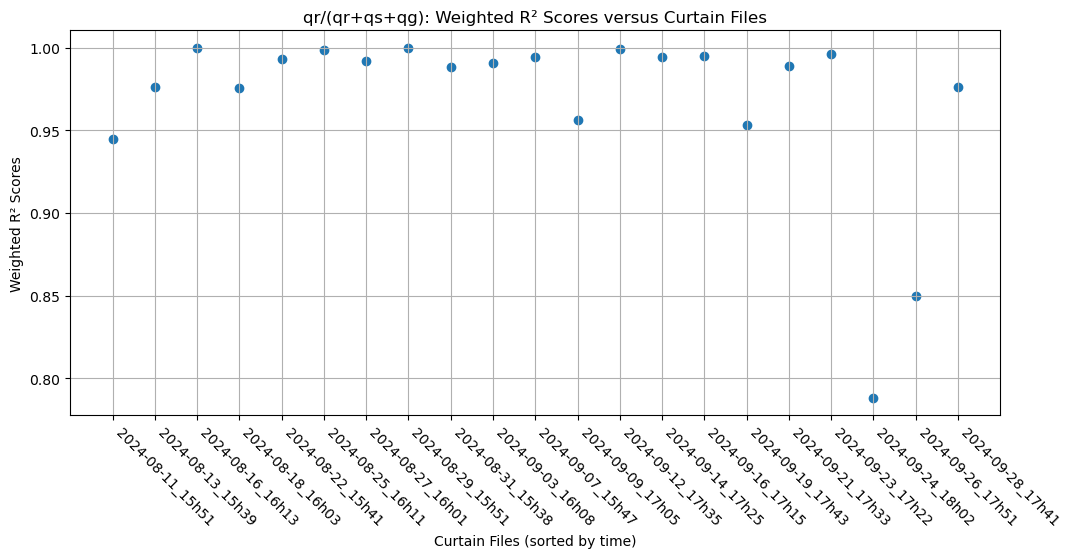

In [43]:
import re

#Extract time from filenames
labels = [re.search(r'(\d{4}-\d{2}-\d{2}_\d{2}h\d{2})', f).group(1) for f in files]

plt.figure(figsize=(12, 5))
# plt.scatter(range(len(files)), r2_curtain_list, marker='o', label='R² Score')
# plt.scatter(range(len(files)), modified_r2_curtain_list, marker='s', label='Modified R² Score')
# plt.scatter(range(len(files)), weighted_r2_curtain_list, marker='o', label='Weighted R² Score')
plt.scatter(range(len(files)), weighted_r2_curtain_list, marker='o')
plt.xticks(range(len(files)), labels, rotation=-45, ha='left')
plt.xlabel('Curtain Files (sorted by time)')
plt.ylabel('Weighted R² Scores')
plt.title('qr/(qr+qs+qg): Weighted R² Scores versus Curtain Files')     
plt.grid()
# plt.legend()
# plt.legend(loc='lower left')
plt.savefig(f"../output/{output_folder_name}/R2_Scores_vs_Curtain_Files.png", dpi=300, bbox_inches="tight")
plt.show()  

T: 96.5532 %
ql+qi: 1.7251 %
RH: 0.9148 %
qr+qg+qs: 0.8069 %


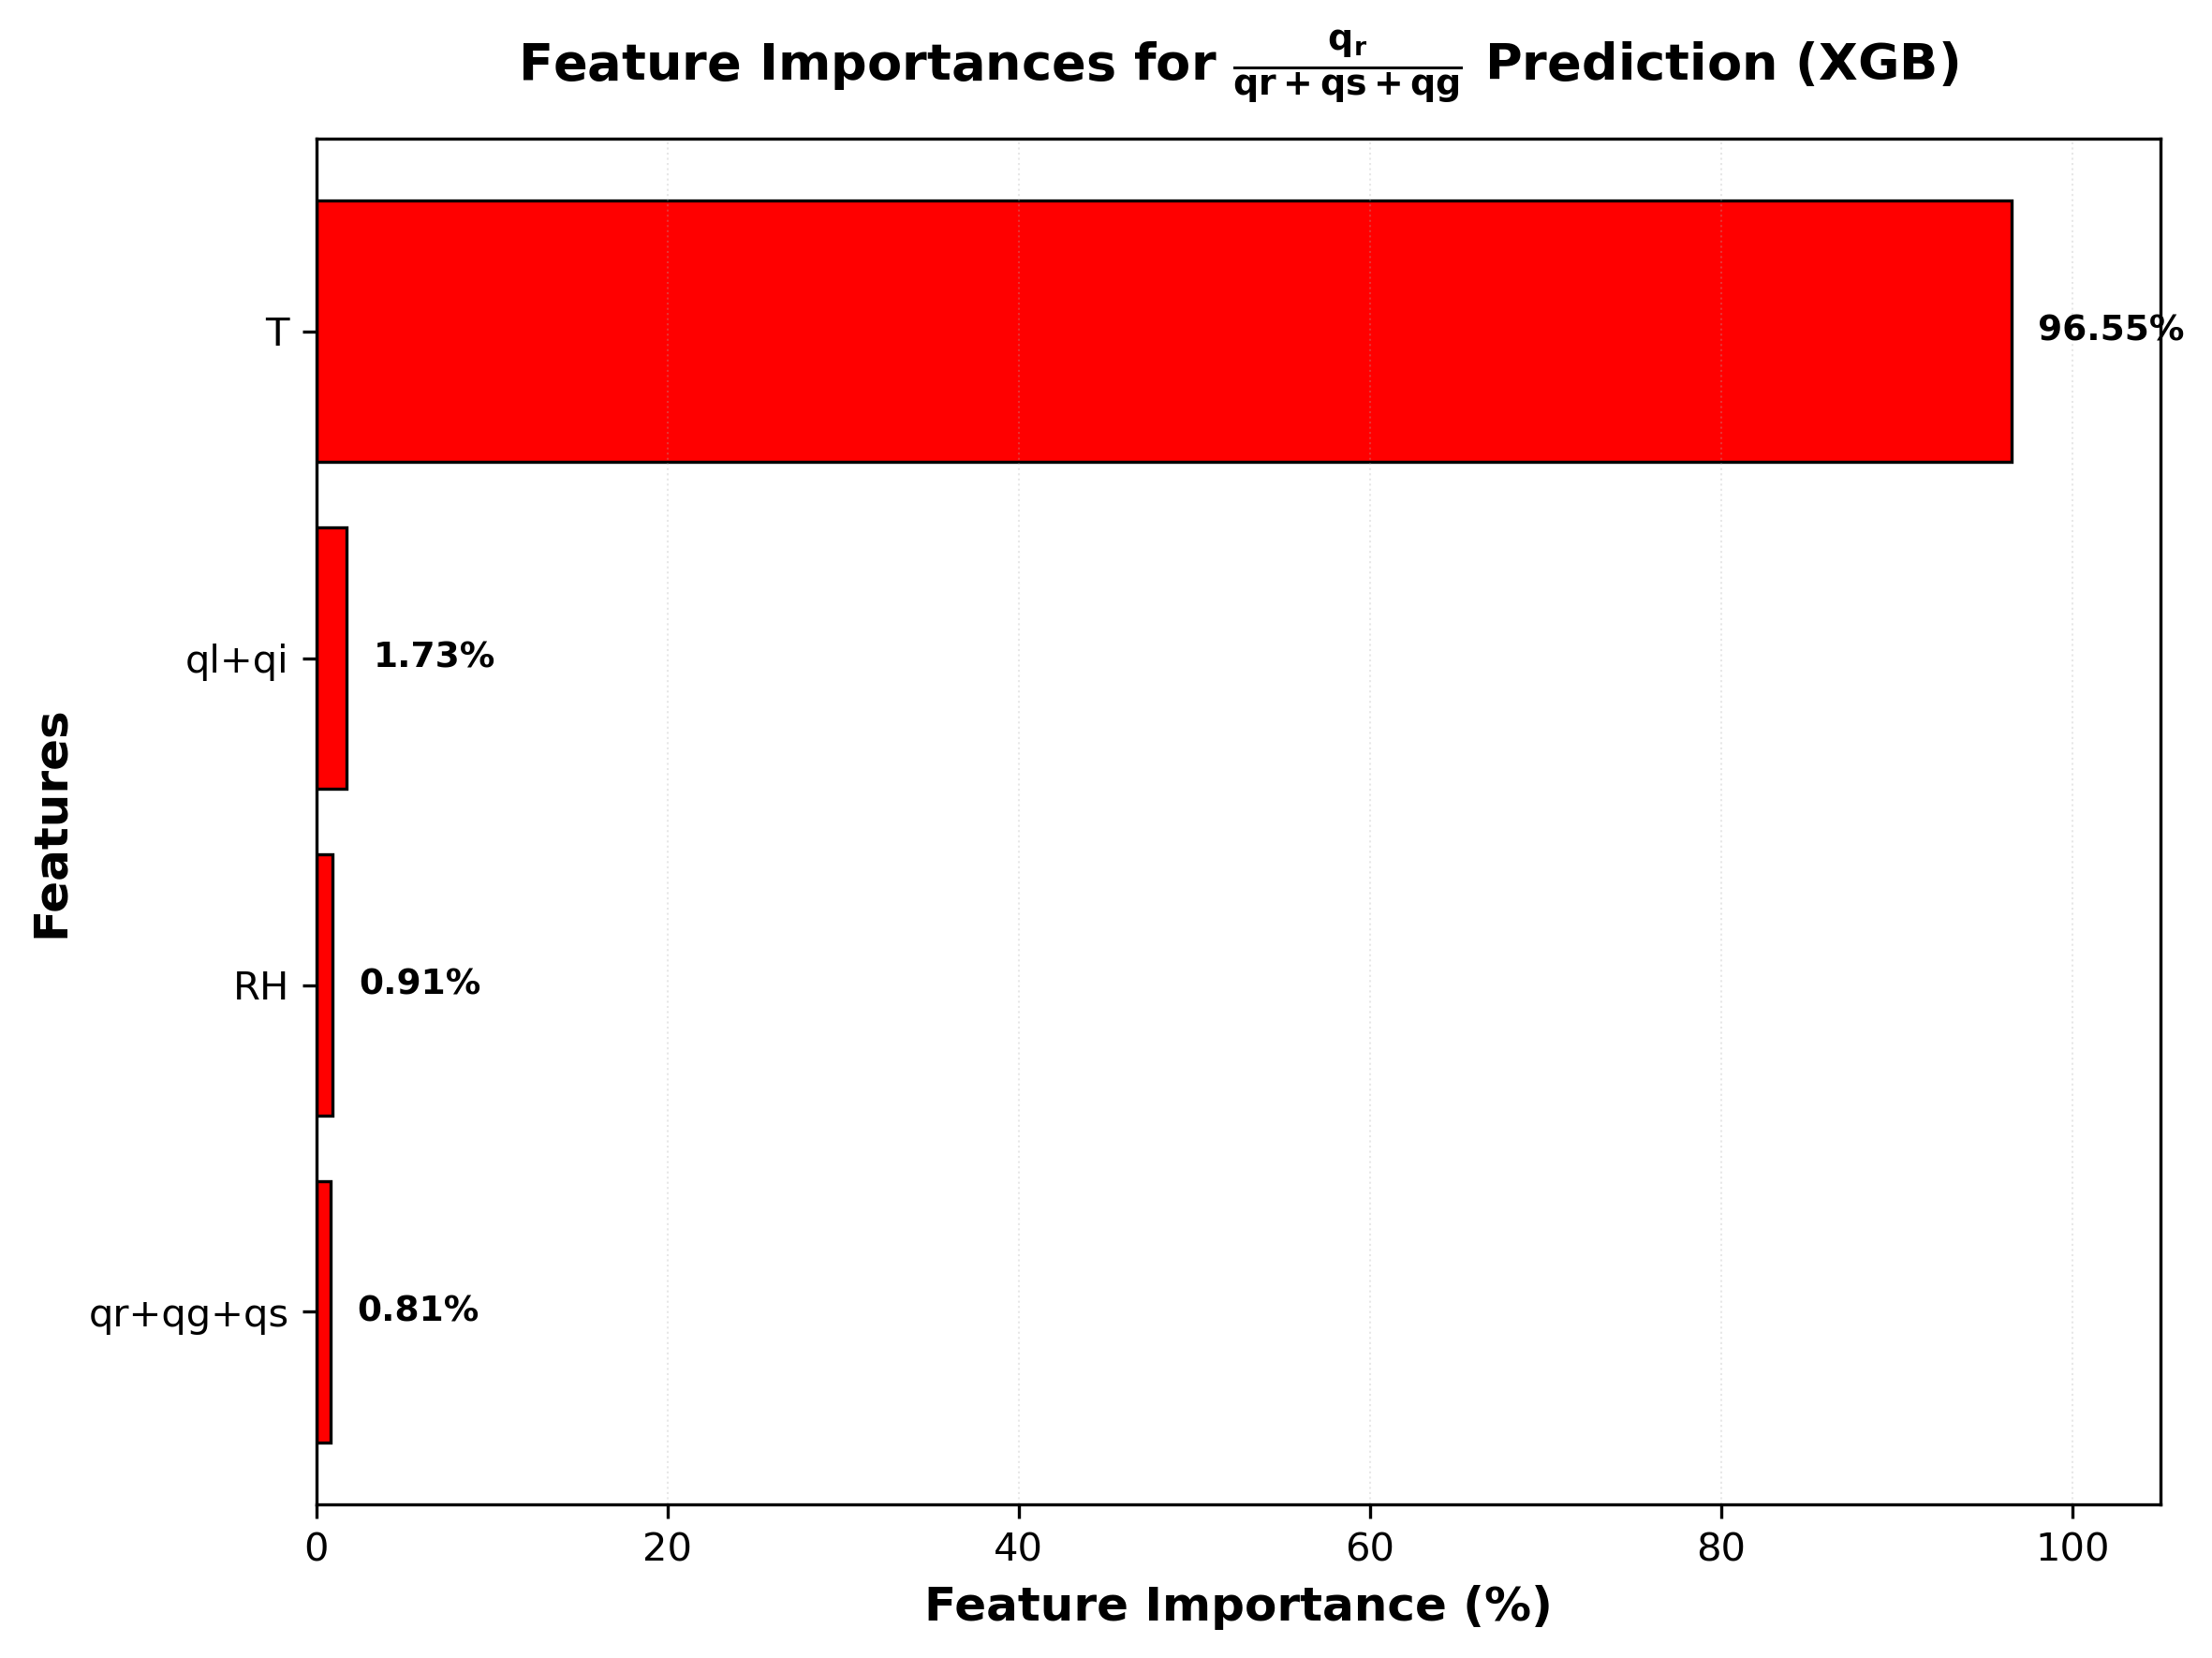

In [44]:
#Feature importance plot
importance = model.feature_importances_

#Combine feature names and scores
feature_scores = list(zip(feature_names, importance))

#Sort by score in descending order
feature_scores.sort(key=lambda x: x[1], reverse=True)

#Convert to percentages
names = []
importances = []

for name, score in feature_scores:
    pct = score * 100
    names.append(name)
    importances.append(pct)
    print(f"{name}: {pct:.4f} %")

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

bars = ax.barh(names, importances, color='red', edgecolor='black', linewidth=0.8)


ax.set_xlabel("Feature Importance (%)", fontsize=12, fontweight='bold')
ax.set_ylabel("Features", fontsize=12, fontweight='bold')
#ax.set_title(r"XGBoost Feature Importance: Ice-Phase Hydrometeor Fraction $\mathbf{\left(\frac{q_g}{q_s + q_g}\right)}$", 
ax.set_title(r"Feature Importances for $\mathbf{\frac{q_r}{qr +qs +qg}}$ Prediction (XGB)", 
            fontsize=13, fontweight='bold', pad=15)

ax.invert_yaxis() #Highest importance at the top

#Add percentage values on bars
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.text(
        width + 1.5,
        y,
        f"{width:.2f}%",
        va="center",
        fontsize=9,
        fontweight='bold'
    )
ax.set_xlim(0, 105)

ax.grid(True, axis='x', alpha=0.3, linestyle=':', linewidth=0.5, zorder=0)

plt.tight_layout()
plt.savefig(f"../output/{output_folder_name}/FeatureImportance.png",
    dpi=300, bbox_inches='tight')

plt.show()


In [45]:
overall_end_time = time.time()
overall_elapsed_time = overall_end_time - overall_start_time
print(f"Overall Elapsed time: {overall_elapsed_time/60:.4f} minutes")

Overall Elapsed time: 14.5234 minutes
